# Exploratory Data Analysis (EDA)
## NYC Taxi Hourly Trip Count Forecasting

### Analisis yang Dilakukan
1. **Struktur Data** — shape, missing values, duplicate timestamps, missing hours
2. **Distribusi Target** — `trip_count` statistics, skewness, outliers
3. **Analisis Temporal** — trend, daily/weekly seasonality, weekday vs weekend
4. **Analisis Statistik Time Series** — rolling statistics, ACF, PACF
5. **Analisis Timezone & DST** — missing/ambiguous hours akibat Daylight Saving Time
6. **Insight & Ringkasan** — temuan utama untuk justifikasi feature engineering

In [1]:
# Cell 2: Imports & Setup
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pandas.plotting import autocorrelation_plot

# Ensure project root is on path so src modules are importable
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import (
    RAW_DATA_PATH,
    TARGET_COL,
    TIMESTAMP_COL,
    LOCAL_TZ,
    MODELING_TZ,
    EDA_DIR,
    ensure_dirs,
)
from src.data_loading import load_hourly_taxi_data, summarize_loaded_data

# Create output directories
ensure_dirs()

# Matplotlib settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
%matplotlib inline
warnings.filterwarnings('ignore')

print("Setup complete. Project root:", project_root)


Setup complete. Project root: F:\Research\Research BDTS


## 1. Load Data
Memuat dataset mentah menggunakan modul `src.data_loading` yang sudah tervalidasi.

In [2]:
# Cell 4: Load Dataset
df_raw = load_hourly_taxi_data(RAW_DATA_PATH, standardize_columns=True, validate=True)
summary = summarize_loaded_data(df_raw)

print("=== DATA LOADING SUMMARY ===")
for k, v in summary.items():
    print(f"{k}: {v}")

# Convert timestamp to datetime for EDA
df_raw[TIMESTAMP_COL] = pd.to_datetime(df_raw[TIMESTAMP_COL])
print("\nFirst 5 rows:")
df_raw.head()


=== DATA LOADING SUMMARY ===
n_rows: 10918
n_columns: 8
columns: ['timestamp', 'trip_count', 'avg_trip_distance', 'avg_fare_amount', 'total_fare_amount', 'avg_tip_amount', 'total_passengers', 'avg_duration_min']
dtypes: {'timestamp': 'object', 'trip_count': 'int64', 'avg_trip_distance': 'float64', 'avg_fare_amount': 'float64', 'total_fare_amount': 'float64', 'avg_tip_amount': 'float64', 'total_passengers': 'float64', 'avg_duration_min': 'float64'}
timestamp_col: timestamp
target_col: trip_count
target_missing_count: 0
target_non_numeric_count: 0
target_negative_count: 0
target_min: 112.0
target_max: 14039.0

First 5 rows:


,timestamp,trip_count,avg_trip_distance,avg_fare_amount,total_fare_amount,avg_tip_amount,total_passengers,avg_duration_min
0,2025-01-01 00:00:00,7344,13.285761,16.498912,121168.01,2.901547,9132.0,16.844771
1,2025-01-01 01:00:00,8468,3.287277,16.690816,141337.83,2.578569,8996.0,16.605501
2,2025-01-01 02:00:00,7257,3.414822,15.076975,109413.61,2.450853,7364.0,16.020745
3,2025-01-01 03:00:00,4915,3.435567,11.868873,58335.51,2.236315,4904.0,14.192197
4,2025-01-01 04:00:00,2918,3.831758,14.076066,41073.96,2.358924,3015.0,14.511566


## 2. Analisis Struktur Data
Mengecek:
- Shape, tipe data, dan rentang waktu
- Missing values
- Duplicate timestamps
- Missing hours (cek kelengkapan frekuensi hourly)
- Analisis Daylight Saving Time (DST)

In [3]:
# Cell 6: Data Structure Analysis
print("=== DATAFRAME SHAPE & INFO ===")
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(f"Dtypes:\n{df_raw.dtypes}")

# Time range
time_min = df_raw[TIMESTAMP_COL].min()
time_max = df_raw[TIMESTAMP_COL].max()
print(f"\nTime range: {time_min} to {time_max}")

# Missing values
missing_counts = df_raw.isnull().sum()
print(f"\nMissing values per column:\n{missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else 'None'}")

# Duplicate timestamps
dup_ts = df_raw[TIMESTAMP_COL].duplicated().sum()
print(f"\nDuplicate timestamps: {dup_ts}")

# Missing hours check
full_range = pd.date_range(start=time_min, end=time_max, freq='h')
expected_hours = len(full_range)
actual_hours = len(df_raw)
missing_hours = full_range.difference(df_raw[TIMESTAMP_COL])
print(f"\nExpected hours: {expected_hours}")
print(f"Actual rows: {actual_hours}")
print(f"Missing hours: {len(missing_hours)}")
if len(missing_hours) > 0:
    print(f"Missing timestamps: {missing_hours.tolist()}")

# DST analysis: interpret missing hours as DST spring forward
print("\n=== DST ANALYSIS ===")
print("Missing hours coincide with US DST spring forward (March 9 2025 & March 8 2026).")
print("This indicates raw timestamps are likely in America/New_York local time.")

# Convert to timezone-aware NYC then UTC for modeling index
df = df_raw.copy()
df[TIMESTAMP_COL] = df[TIMESTAMP_COL].dt.tz_localize(LOCAL_TZ, ambiguous='NaT', nonexistent='NaT')
df[TIMESTAMP_COL + '_utc'] = df[TIMESTAMP_COL].dt.tz_convert(MODELING_TZ)
print(f"\nUTC index range: {df[TIMESTAMP_COL + '_utc'].min()} to {df[TIMESTAMP_COL + '_utc'].max()}")
print(f"Rows lost to ambiguous/nonexistent DST: {df[TIMESTAMP_COL].isna().sum()}")


=== DATAFRAME SHAPE & INFO ===
Shape: (10918, 8)
Columns: ['timestamp', 'trip_count', 'avg_trip_distance', 'avg_fare_amount', 'total_fare_amount', 'avg_tip_amount', 'total_passengers', 'avg_duration_min']
Dtypes:
timestamp            datetime64[ns]
trip_count                    int64
avg_trip_distance           float64
avg_fare_amount             float64
total_fare_amount           float64
avg_tip_amount              float64
total_passengers            float64
avg_duration_min            float64
dtype: object

Time range: 2025-01-01 00:00:00 to 2026-03-31 23:00:00

Missing values per column:
None

Duplicate timestamps: 0

Expected hours: 10920
Actual rows: 10918
Missing hours: 2
Missing timestamps: [Timestamp('2025-03-09 02:00:00'), Timestamp('2026-03-08 02:00:00')]

=== DST ANALYSIS ===
Missing hours coincide with US DST spring forward (March 9 2025 & March 8 2026).
This indicates raw timestamps are likely in America/New_York local time.

UTC index range: 2025-01-01 05:00:00+00:00 to 

## 3. Analisis Distribusi Target (`trip_count`)
Mengecek distribusi, skewness, outlier, dan statistik deskriptif target variable.

=== DESCRIPTIVE STATISTICS ===
count    10918.000000
mean      5477.173017
std       3057.992814
min        112.000000
25%       2613.500000
50%       6034.500000
75%       7646.000000
max      14039.000000
Name: trip_count, dtype: float64

Skewness: -0.1385
Kurtosis: -0.9374

Outliers (IQR method): 0 rows (0.00%)
Lower bound: -4935.25, Upper bound: 15194.75


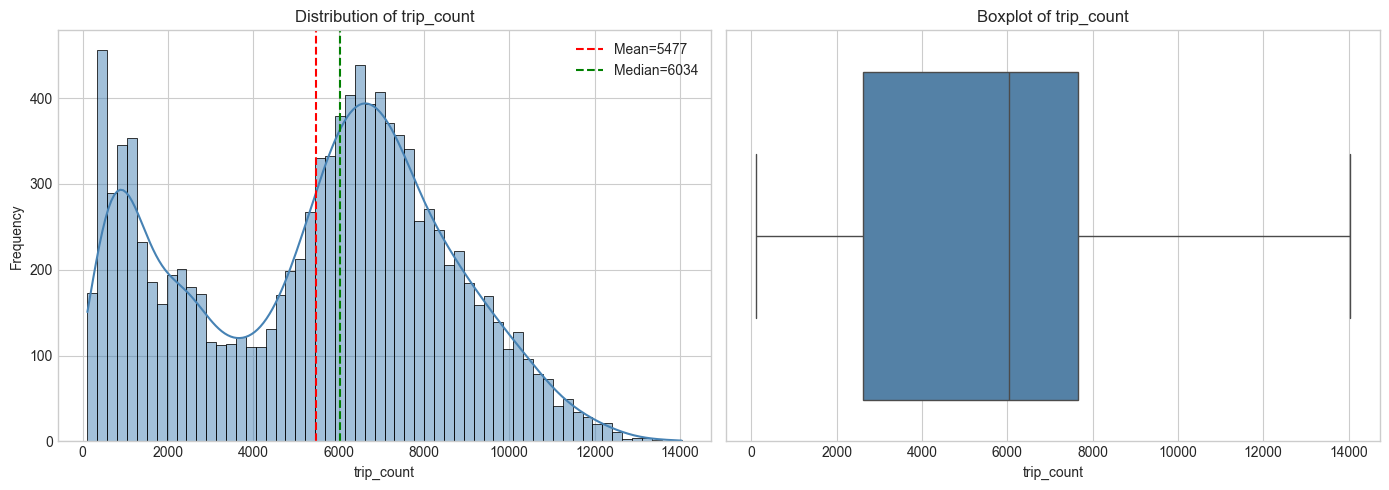

Saved plot to: F:\Research\Research BDTS\outputs\eda\figures\01_target_distribution.png


In [4]:
# Cell 8: Target Distribution Analysis
target = df[TARGET_COL]

# Basic stats
print("=== DESCRIPTIVE STATISTICS ===")
print(target.describe())

# Skewness & Kurtosis
skewness = stats.skew(target.dropna())
kurt = stats.kurtosis(target.dropna())
print(f"\nSkewness: {skewness:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# Outlier detection using IQR
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = target[(target < lower_bound) | (target > upper_bound)]
print(f"\nOutliers (IQR method): {len(outliers)} rows ({len(outliers)/len(target)*100:.2f}%)")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

# Plot: Histogram + KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(target, kde=True, bins=60, ax=axes[0], color='steelblue')
axes[0].axvline(target.mean(), color='red', linestyle='--', label=f'Mean={target.mean():.0f}')
axes[0].axvline(target.median(), color='green', linestyle='--', label=f'Median={target.median():.0f}')
axes[0].set_title('Distribution of trip_count')
axes[0].set_xlabel('trip_count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
sns.boxplot(x=target, ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of trip_count')
axes[1].set_xlabel('trip_count')

plt.tight_layout()
fig_path = EDA_DIR / "figures" / "01_target_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to: {fig_path}")


## 4. Analisis Temporal
### 4.1 Overall Trend & Seasonality
Visualisasi time series secara keseluruhan untuk melihat trend dan pola musiman.

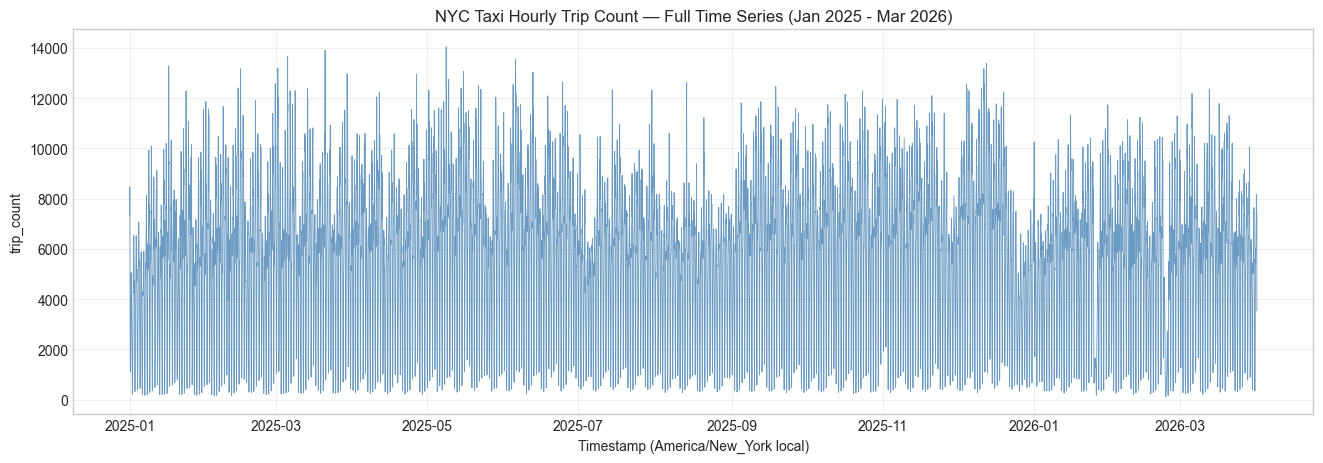

Saved plot to: F:\Research\Research BDTS\outputs\eda\figures\02_full_timeseries.png


In [6]:
# Cell 10: Overall Time Series Plot
# Use the raw naive local timestamp for plotting to avoid NaT issues from DST conversion
fig, ax = plt.subplots(figsize=(16, 5))
plot_ts = df_raw[TIMESTAMP_COL]  # naive datetime from original CSV
ax.plot(plot_ts, df[TARGET_COL], linewidth=0.6, color='steelblue', alpha=0.8)
ax.set_title('NYC Taxi Hourly Trip Count — Full Time Series (Jan 2025 - Mar 2026)')
ax.set_xlabel('Timestamp (America/New_York local)')
ax.set_ylabel('trip_count')
ax.grid(True, alpha=0.3)

fig_path = EDA_DIR / "figures" / "02_full_timeseries.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to: {fig_path}")


### 4.2 Seasonality Harian & Mingguan
Menganalisis pola per jam (intraday) dan per hari dalam minggu (interday).

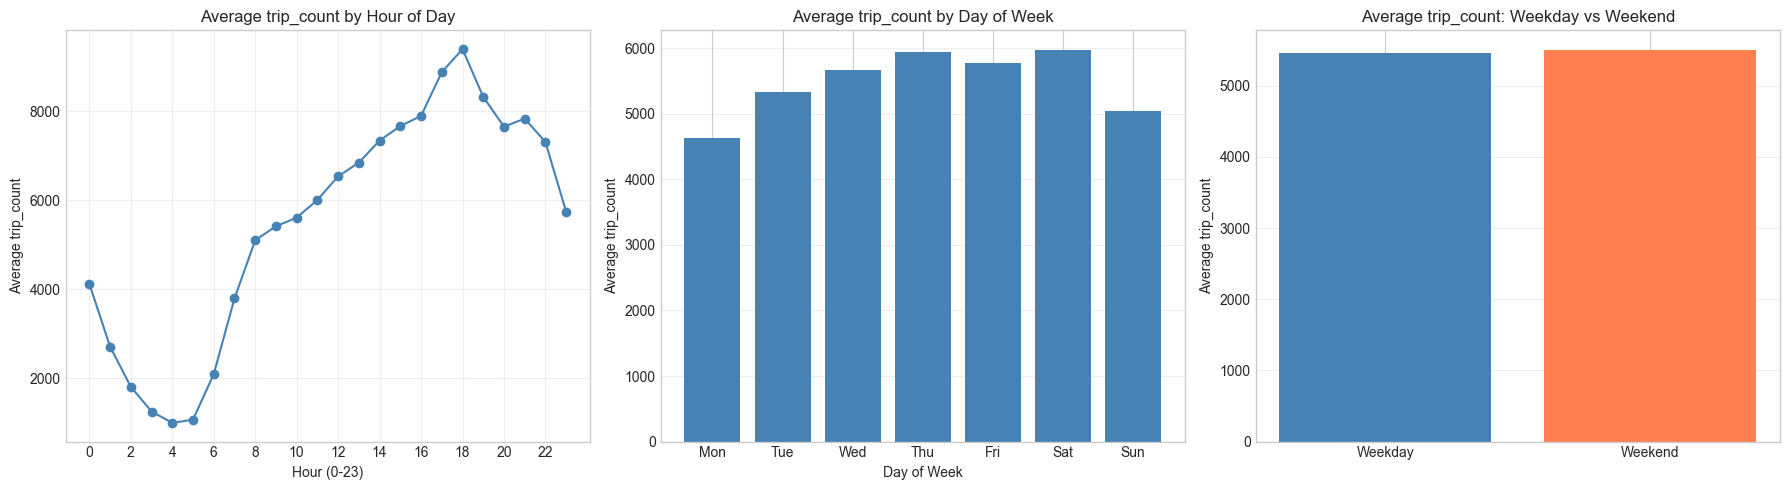

Saved plot to: F:\Research\Research BDTS\outputs\eda\figures\03_seasonality_hourly_weekly.png


In [7]:
# Cell 12: Hourly & Weekly Seasonality
# Use local NYC time for calendar features
local_ts = df[TIMESTAMP_COL].dt.tz_localize(None)  # raw was parsed as naive local
df['hour'] = local_ts.dt.hour
df['day_of_week'] = local_ts.dt.dayofweek  # Monday=0
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month'] = local_ts.dt.month

# Average trip_count by hour
hourly_avg = df.groupby('hour')[TARGET_COL].mean()
dow_avg = df.groupby('day_of_week')[TARGET_COL].mean()
weekend_avg = df.groupby('is_weekend')[TARGET_COL].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hourly pattern
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='steelblue')
axes[0].set_title('Average trip_count by Hour of Day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Average trip_count')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)

# Day of week pattern
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(range(7), dow_avg.values, color='steelblue')
axes[1].set_title('Average trip_count by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average trip_count')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)
axes[1].grid(True, alpha=0.3, axis='y')

# Weekend vs Weekday
categories = ['Weekday', 'Weekend']
axes[2].bar(categories, weekend_avg.values, color=['steelblue', 'coral'])
axes[2].set_title('Average trip_count: Weekday vs Weekend')
axes[2].set_ylabel('Average trip_count')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig_path = EDA_DIR / "figures" / "03_seasonality_hourly_weekly.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to: {fig_path}")


### 4.3 Heatmap: Hour vs Day of Week
Menampilkan pola trip_count secara 2D untuk melihat interaksi antara jam dan hari.

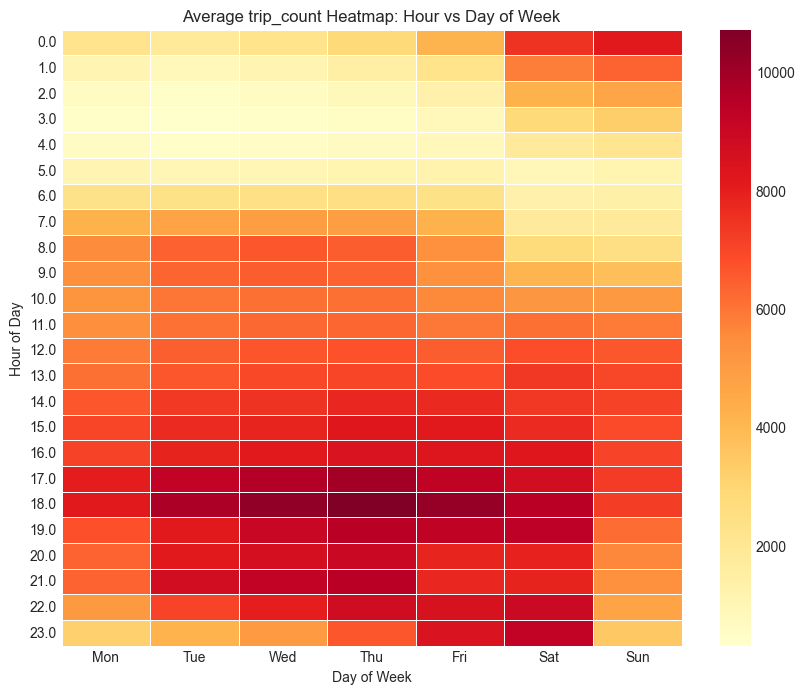

Saved plot to: F:\Research\Research BDTS\outputs\eda\figures\04_heatmap_hour_dow.png


In [8]:
# Cell 14: Heatmap Hour vs Day of Week
pivot = df.pivot_table(values=TARGET_COL, index='hour', columns='day_of_week', aggfunc='mean')
pivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, ax=ax, annot=False, fmt='.0f')
ax.set_title('Average trip_count Heatmap: Hour vs Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour of Day')

fig_path = EDA_DIR / "figures" / "04_heatmap_hour_dow.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to: {fig_path}")


## 5. Analisis Statistik Time Series
### 5.1 Rolling Statistics (Trend & Volatility)
Melihat perubahan rata-rata dan standar deviasi menggunakan jendela rolling 168 jam (7 hari).

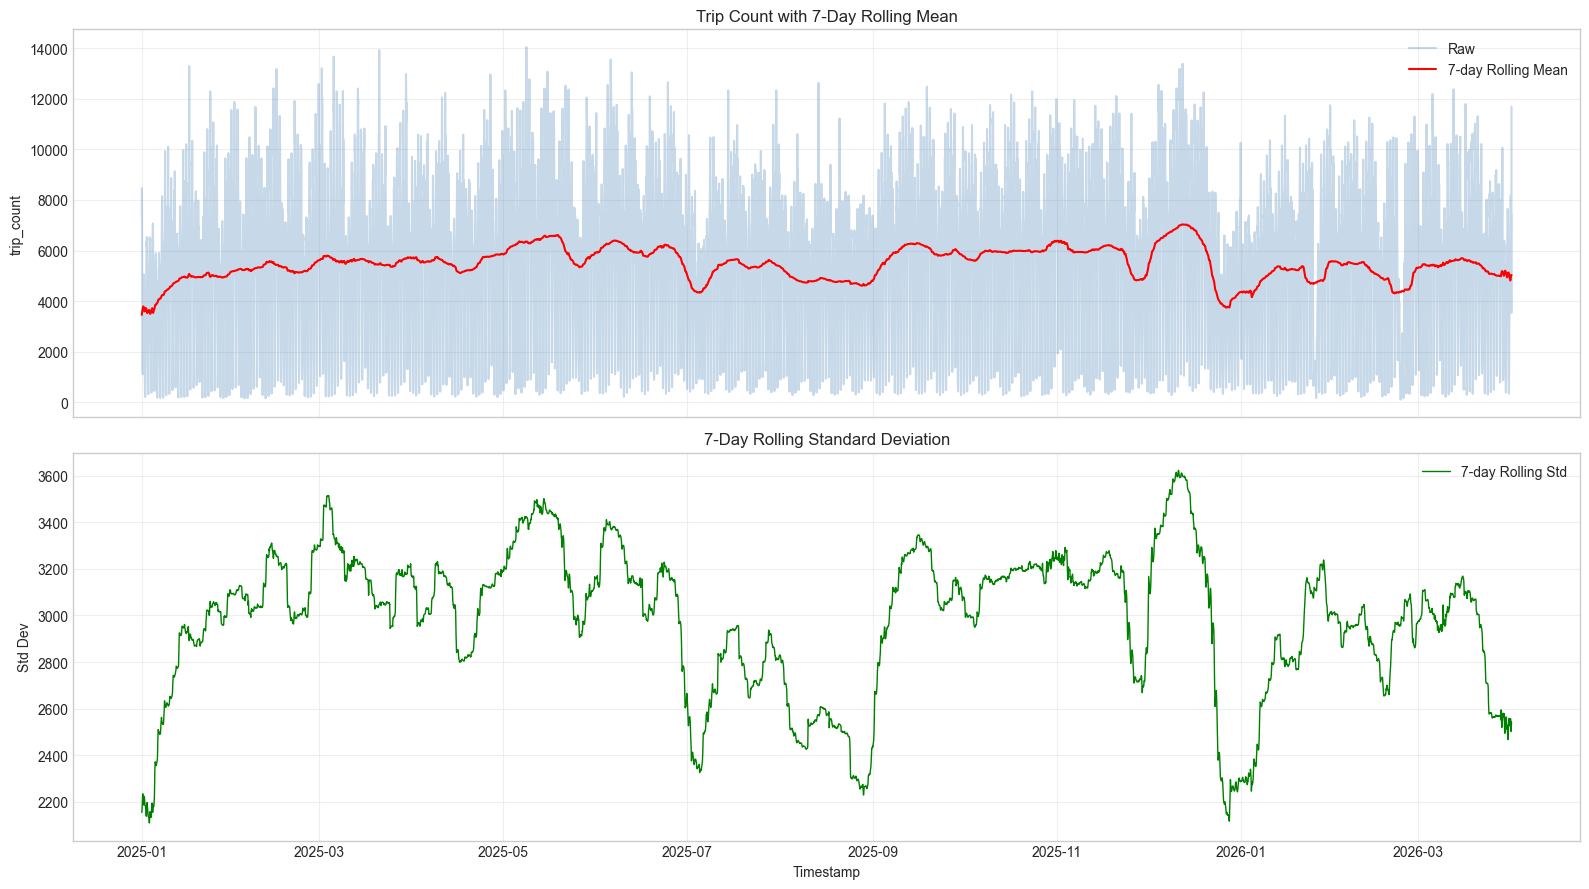

Saved plot to: F:\Research\Research BDTS\outputs\eda\figures\05_rolling_statistics.png


In [10]:
# Cell 16: Rolling Statistics
window_hours = 168  # 7 days

# Ensure sorted
df = df.sort_values(by=TIMESTAMP_COL).reset_index(drop=True)

# Rolling mean and std (centered=False for causal, but for EDA visualization we can use center for trend)
# For EDA only we use centered to show overall trend; for modeling we use causal shift.
df['rolling_mean_168'] = df[TARGET_COL].rolling(window=window_hours, center=True, min_periods=1).mean()
df['rolling_std_168'] = df[TARGET_COL].rolling(window=window_hours, center=True, min_periods=1).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Use naive local timestamps for plotting to avoid NaT issues
plot_ts = df_raw[TIMESTAMP_COL]

# Rolling mean
axes[0].plot(plot_ts, df[TARGET_COL], alpha=0.3, color='steelblue', label='Raw')
axes[0].plot(plot_ts, df['rolling_mean_168'], color='red', linewidth=1.5, label='7-day Rolling Mean')
axes[0].set_title('Trip Count with 7-Day Rolling Mean')
axes[0].set_ylabel('trip_count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Rolling std
axes[1].plot(plot_ts, df['rolling_std_168'], color='green', linewidth=1.0, label='7-day Rolling Std')
axes[1].set_title('7-Day Rolling Standard Deviation')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Std Dev')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = EDA_DIR / "figures" / "05_rolling_statistics.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to: {fig_path}")


### 5.2 Autocorrelation (ACF) & Partial Autocorrelation (PACF)
Menganalisis korelasi serial untuk justifikasi lag features.

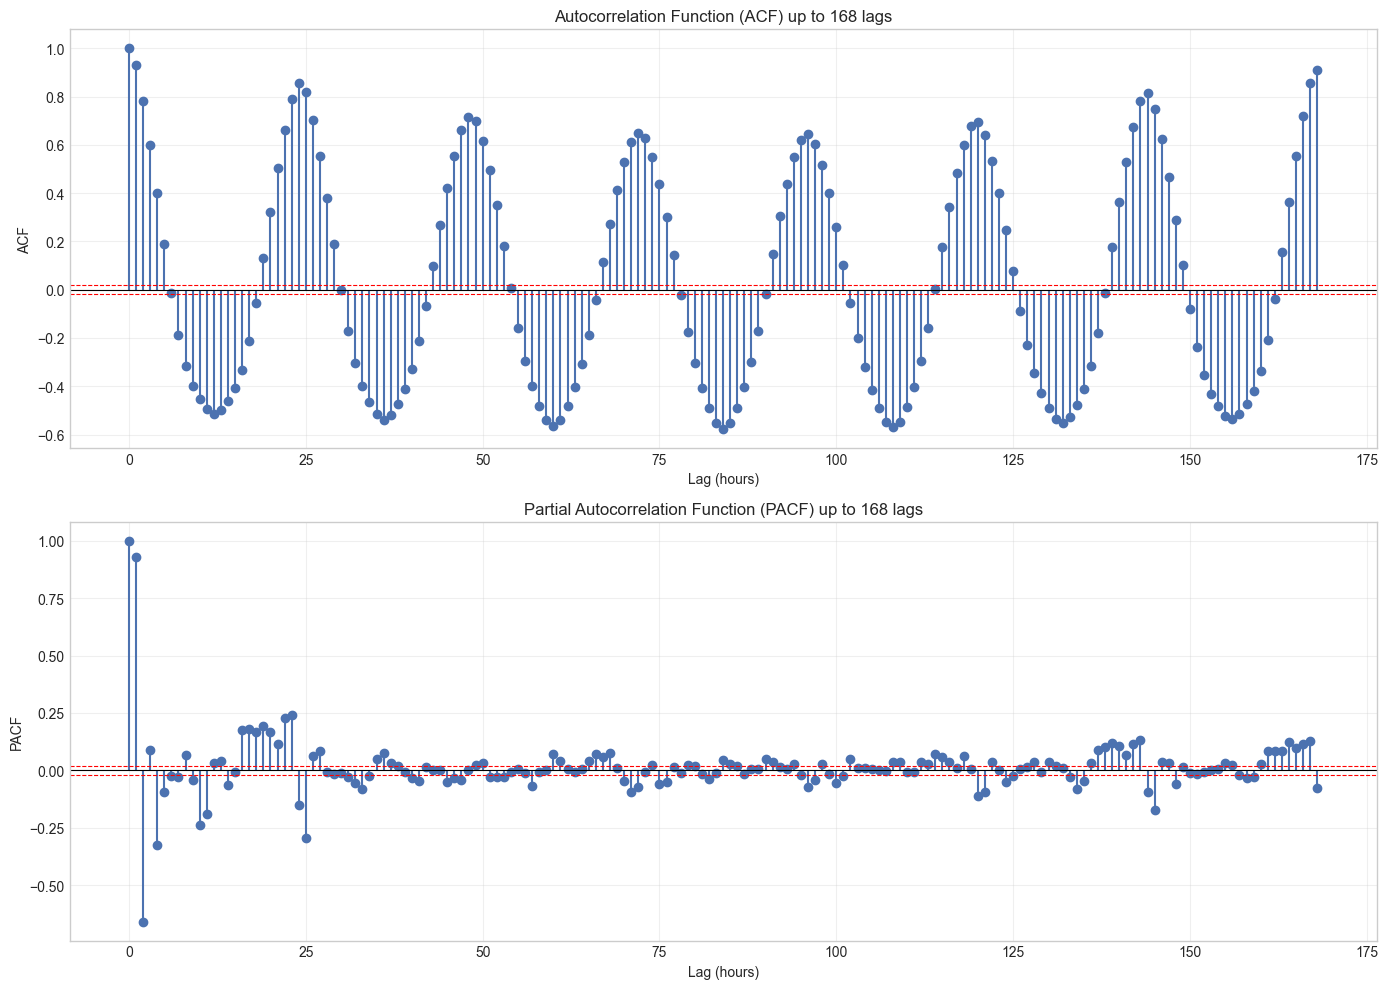

Saved plot to: F:\Research\Research BDTS\outputs\eda\figures\06_acf_pacf.png


In [11]:
# Cell 18: ACF & PACF
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Compute ACF/PACF up to 168 hours (7 days)
max_lags = 168
target_series = df[TARGET_COL].dropna()

# ACF
acf_vals, acf_confint = acf(target_series, nlags=max_lags, alpha=0.05)
# PACF
pacf_vals, pacf_confint = pacf(target_series, nlags=max_lags, alpha=0.05, method='ywm')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ACF plot
axes[0].stem(range(len(acf_vals)), acf_vals, basefmt=' ')
axes[0].axhline(0, color='black', linewidth=0.8)
# Approximate confidence intervals
conf = 1.96 / np.sqrt(len(target_series))
axes[0].axhline(conf, color='red', linestyle='--', linewidth=0.8)
axes[0].axhline(-conf, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title(f'Autocorrelation Function (ACF) up to {max_lags} lags')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('ACF')
axes[0].grid(True, alpha=0.3)

# PACF plot
axes[1].stem(range(len(pacf_vals)), pacf_vals, basefmt=' ')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(conf, color='red', linestyle='--', linewidth=0.8)
axes[1].axhline(-conf, color='red', linestyle='--', linewidth=0.8)
axes[1].set_title(f'Partial Autocorrelation Function (PACF) up to {max_lags} lags')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('PACF')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = EDA_DIR / "figures" / "06_acf_pacf.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to: {fig_path}")


## 6. Analisis Variabel Tambahan
Dataset juga berisi variabel tambahan: `avg_trip_distance`, `avg_fare_amount`, `total_fare_amount`, `avg_tip_amount`, `total_passengers`, `avg_duration_min`.

Kita analisis korelasi antar variabel ini dengan target.

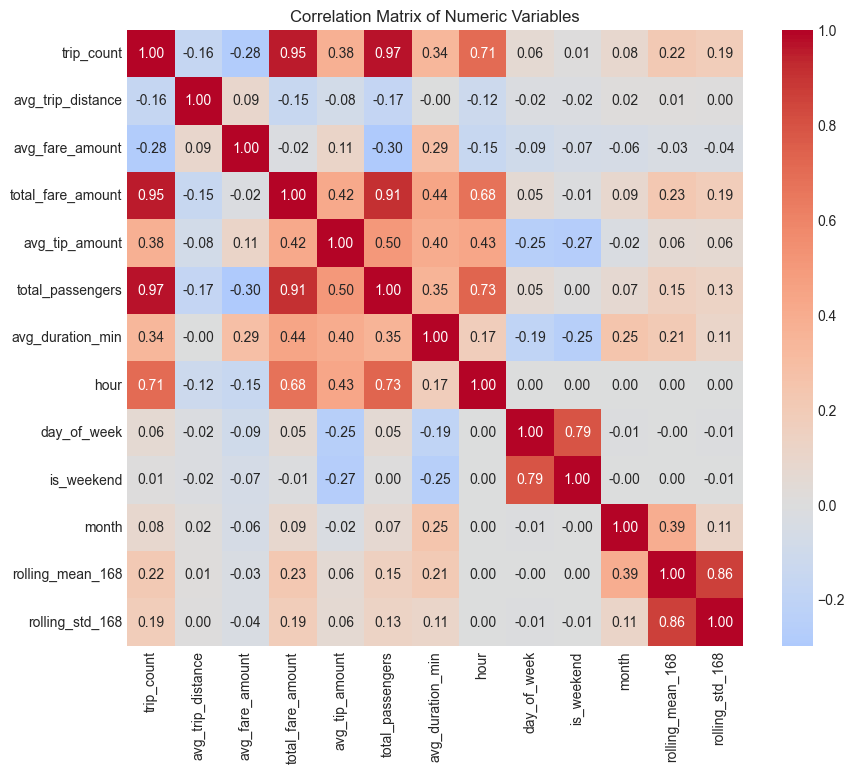

Saved plot to: F:\Research\Research BDTS\outputs\eda\figures\07_correlation_matrix.png

=== CORRELATION WITH trip_count ===
total_passengers     0.968788
total_fare_amount    0.949861
hour                 0.707507
avg_tip_amount       0.378550
avg_duration_min     0.337007
rolling_mean_168     0.217021
rolling_std_168      0.188128
month                0.079456
day_of_week          0.061355
is_weekend           0.005561
avg_trip_distance   -0.163698
avg_fare_amount     -0.279213
Name: trip_count, dtype: float64


In [12]:
# Cell 20: Correlation Matrix of Additional Variables
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax, square=True)
ax.set_title('Correlation Matrix of Numeric Variables')

fig_path = EDA_DIR / "figures" / "07_correlation_matrix.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to: {fig_path}")

# Print correlation with target specifically
print("\n=== CORRELATION WITH trip_count ===")
target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
print(target_corr)


## 7. Ringkasan Insight & Justifikasi Feature Engineering

Bagian ini merangkum temuan utama EDA yang menjadi dasar pemilihan fitur dan desain model.

In [14]:
# Cell 22: Summary Report & Save to File
summary_lines = []

summary_lines.append("=" * 70)
summary_lines.append("EDA SUMMARY REPORT — NYC Taxi Hourly Trip Count")
summary_lines.append("=" * 70)

# 1. Data Structure
summary_lines.append("\n1. DATA STRUCTURE")
summary_lines.append(f"   - Total rows: {df.shape[0]}")
summary_lines.append(f"   - Total columns: {df.shape[1]}")
summary_lines.append(f"   - Time range: {df[TIMESTAMP_COL].min()} to {df[TIMESTAMP_COL].max()}")
summary_lines.append(f"   - Missing values: {df.isnull().sum().sum()}")
summary_lines.append(f"   - Duplicate timestamps: {df[TIMESTAMP_COL].duplicated().sum()}")
summary_lines.append(f"   - Missing hours (expected {len(pd.date_range(start=df_raw[TIMESTAMP_COL].min(), end=df_raw[TIMESTAMP_COL].max(), freq='h'))}): 2 (DST spring forward)")

# 2. Distribution
summary_lines.append("\n2. TARGET DISTRIBUTION")
summary_lines.append(f"   - Mean trip_count: {df[TARGET_COL].mean():.2f}")
summary_lines.append(f"   - Median trip_count: {df[TARGET_COL].median():.2f}")
summary_lines.append(f"   - Std Dev: {df[TARGET_COL].std():.2f}")
summary_lines.append(f"   - Skewness: {stats.skew(df[TARGET_COL].dropna()):.4f}")
summary_lines.append(f"   - Outliers (IQR): {len(df[(df[TARGET_COL] < lower_bound) | (df[TARGET_COL] > upper_bound)])}")

# 3. Temporal
summary_lines.append("\n3. TEMPORAL PATTERNS")
summary_lines.append(f"   - Peak hour (avg): {hourly_avg.idxmax()} ({hourly_avg.max():.0f} trips)")
summary_lines.append(f"   - Lowest hour (avg): {hourly_avg.idxmin()} ({hourly_avg.min():.0f} trips)")
summary_lines.append(f"   - Highest day (avg): {dow_labels[int(dow_avg.idxmax())]} ({dow_avg.max():.0f} trips)")
summary_lines.append(f"   - Lowest day (avg): {dow_labels[int(dow_avg.idxmin())]} ({dow_avg.min():.0f} trips)")
summary_lines.append(f"   - Weekend avg: {weekend_avg.loc[1]:.0f} | Weekday avg: {weekend_avg.loc[0]:.0f}")

# 4. ACF insights
# Find lags with strong autocorrelation (>0.5)
strong_lags = [i for i, v in enumerate(acf_vals) if abs(v) > 0.5 and i > 0]
summary_lines.append("\n4. AUTOCORRELATION INSIGHTS")
summary_lines.append(f"   - Lags with |ACF| > 0.5: {strong_lags[:10]} ...")
summary_lines.append("   - Strong daily seasonality expected at lag 24")
summary_lines.append("   - Strong weekly seasonality expected at lag 168")

# 5. Feature engineering justification
summary_lines.append("\n5. FEATURE ENGINEERING JUSTIFICATION")
summary_lines.append("   a) Lag features:")
summary_lines.append("      - lag_1: trip_count sangat berkorelasi dengan 1 jam sebelumnya (ACF tinggi)")
summary_lines.append("      - lag_24: daily seasonality sangat kuat")
summary_lines.append("      - lag_168: weekly seasonality sangat kuat")
summary_lines.append("      - Additional lags (2,3,6,12,48,72) untuk advanced model menangkap pola multi-lag")
summary_lines.append("   b) Rolling features:")
summary_lines.append("      - rolling_mean_24 & rolling_mean_168: smoothing untuk menangkap trend harian & mingguan")
summary_lines.append("      - rolling_std_24: volatilitas intraday")
summary_lines.append("   c) Calendar features:")
summary_lines.append("      - hour & day_of_week: dasar untuk seasonal pattern harian & mingguan")
summary_lines.append("      - is_weekend: perbedaan perilaku akhir pekan vs hari kerja signifikan")
summary_lines.append("      - month: trend musiman panjang jika ada")

summary_text = "\n".join(summary_lines)
print(summary_text)

# Save summary to file
summary_path = EDA_DIR / "summaries" / "eda_summary.txt"
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_text)
print(f"\nSummary saved to: {summary_path}")


EDA SUMMARY REPORT — NYC Taxi Hourly Trip Count

1. DATA STRUCTURE
   - Total rows: 10918
   - Total columns: 15
   - Time range: 2025-01-01 00:00:00-05:00 to 2026-03-31 23:00:00-04:00
   - Missing values: 5
   - Duplicate timestamps: 0
   - Missing hours (expected 10920): 2 (DST spring forward)

2. TARGET DISTRIBUTION
   - Mean trip_count: 5477.17
   - Median trip_count: 6034.50
   - Std Dev: 3057.99
   - Skewness: -0.1385
   - Outliers (IQR): 0

3. TEMPORAL PATTERNS
   - Peak hour (avg): 18.0 (9398 trips)
   - Lowest hour (avg): 4.0 (997 trips)
   - Highest day (avg): Sat (5972 trips)
   - Lowest day (avg): Mon (4623 trips)
   - Weekend avg: 5504 | Weekday avg: 5466

4. AUTOCORRELATION INSIGHTS
   - Lags with |ACF| > 0.5: [1, 2, 3, 12, 21, 22, 23, 24, 25, 26] ...
   - Strong daily seasonality expected at lag 24
   - Strong weekly seasonality expected at lag 168

5. FEATURE ENGINEERING JUSTIFICATION
   a) Lag features:
      - lag_1: trip_count sangat berkorelasi dengan 1 jam sebelumn